In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

# Importando os datasets do Kaggle para o notebook, vou fazer o processo de limpeza, onde irei padronizar os nomes dos jogos, deixando tudo em letra minuscula, outra limpeza que precisamos fazer na nossa base de dados é remover jogos em que não temos informações sobre as suas vendas, algumas empresas não divulgam esses dados, vamos plotar no nosso grafico vendas x notas em cada eixo, se não temos uma dessas informações o jogo não aparecera no grafico, empresas como a Nintendo por exemplo, não divulgam esses dados, então é provavel que não apareça nenhum exclusivo deles no grafico, além disso precisamos somar as vendas em todas as plataformas, no dataset inicial que baixamos do kaggle, as vendas e a nota vem separada por plataforma, então um jogo como GTA V por exemplo, apareceria mais de uma vez por ter sido lancado em varias plataformas diferentes.

In [2]:
df_vendas = (
    pd.read_csv('dados/vendas2024.csv')
    .assign(title=lambda x: x['title'].astype(str).str.lower().str.strip())
    .dropna(subset=['total_sales'])
    .groupby('title', as_index=False)
    .agg({
        'total_sales': 'sum',
        'genre': 'first'  
    })
)

In [3]:
df_meta = (
    pd.read_csv('dados/metacritic.csv')
    .assign(name=lambda x: x['name'].astype(str).str.lower().str.strip())
    .dropna(subset=['meta_score'])
    .groupby('name', as_index=False)['meta_score'].mean()
)

In [4]:
df_mestre = pd.merge(df_vendas, df_meta, left_on='title', right_on='name', how='inner')

# Agora vou cruzar as duas listas e manter apenas os jogos que estão presentes nas duas, queremos no nosso grafico apenas jogos que tem as duas informações, isso finaliza a primeira etapa de limpeza das nossas bases de dados.

In [5]:
df_mestre = pd.merge(
    df_vendas, 
    df_meta, 
    left_on='title', 
    right_on='name', 
    how='inner' 
)


# Olhando agora para o top 10 de notas e top 10 de vendas

In [6]:
top10_notas = df_mestre.nlargest(10, 'meta_score')
top10_notas

,title,total_sales,genre,name,meta_score
2861,nfl 2k1,1.09,Sports,nfl 2k1,97.000000
1694,grand theft auto v,64.29,Action,grand theft auto v,96.800000
4689,uncharted 2: among thieves,6.74,Action,uncharted 2: among thieves,96.000000
3325,red dead redemption 2,19.71,Action-Adventure,red dead redemption 2,95.666667
353,bioshock,4.27,Shooter,bioshock,95.333333
1692,grand theft auto iv,22.53,Action,grand theft auto iv,95.333333
1691,grand theft auto iii,13.11,Action,grand theft auto iii,95.000000
3148,portal 2,3.79,Shooter,portal 2,95.000000
3324,red dead redemption,13.07,Action,red dead redemption,95.000000
2354,mass effect 2,4.95,Role-Playing,mass effect 2,94.666667


In [7]:
top10_vendas = df_mestre.nlargest(10, 'total_sales')
top10_vendas

,title,total_sales,genre,name,meta_score
1694,grand theft auto v,64.29,Action,grand theft auto v,96.800000
540,call of duty: black ops,30.99,Shooter,call of duty: black ops,82.000000
546,call of duty: modern warfare 3,30.71,Shooter,call of duty: modern warfare 3,81.000000
541,call of duty: black ops ii,29.59,Shooter,call of duty: black ops ii,80.250000
543,call of duty: ghosts,28.80,Shooter,call of duty: ghosts,73.600000
545,call of duty: modern warfare 2,25.02,Shooter,call of duty: modern warfare 2,91.333333
2500,minecraft,24.01,Misc,minecraft,89.500000
1692,grand theft auto iv,22.53,Action,grand theft auto iv,95.333333
539,call of duty: advanced warfare,21.78,Shooter,call of duty: advanced warfare,80.666667
4222,the elder scrolls v: skyrim,20.51,Role-Playing,the elder scrolls v: skyrim,91.500000


# Plotando o grafico, escolhi representar o top 10 de vendas, top 10 de notas e a massa geral de dados, isso da uma visualização geral do que as notas estão fazendo com o numero de vendas dos jogos, como as notas da critica saem antes do lançamento dos jogos é possivel ver se as notas estão puxando o publico para os jogos.

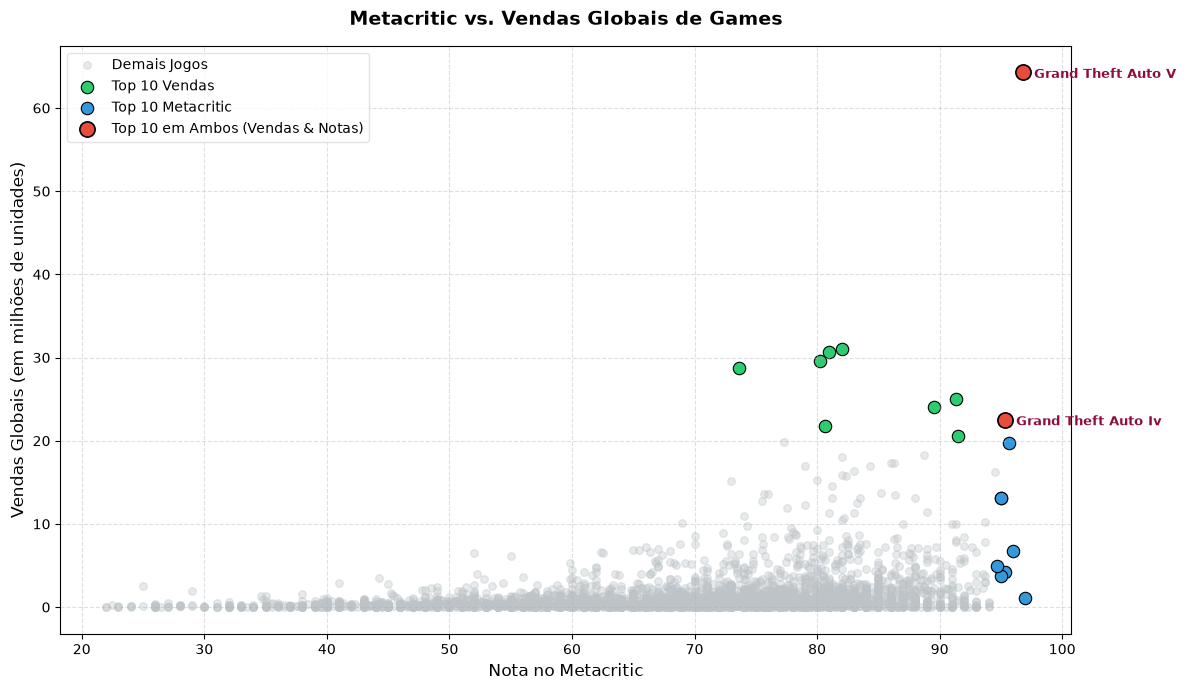

In [8]:
import matplotlib.pyplot as plt


idx_vendas = set(df_mestre.nlargest(10, 'total_sales').index)
idx_notas = set(df_mestre.nlargest(10, 'meta_score').index)


idx_ambos = idx_vendas.intersection(idx_notas)
idx_apenas_vendas = idx_vendas - idx_ambos
idx_apenas_notas = idx_notas - idx_ambos
idx_geral = set(df_mestre.index) - (idx_vendas | idx_notas)


df_geral = df_mestre.loc[list(idx_geral)]
df_apenas_vendas = df_mestre.loc[list(idx_apenas_vendas)]
df_apenas_notas = df_mestre.loc[list(idx_apenas_notas)]
df_ambos = df_mestre.loc[list(idx_ambos)]


fig, ax = plt.subplots(figsize=(12, 7))


ax.scatter(
    df_geral['meta_score'], 
    df_geral['total_sales'], 
    color='#bdc3c7', 
    alpha=0.35, 
    s=30, 
    label='Demais Jogos'
)


ax.scatter(
    df_apenas_vendas['meta_score'], 
    df_apenas_vendas['total_sales'], 
    color='#2ecc71', 
    s=80, 
    edgecolor='black', 
    linewidth=0.8,
    label='Top 10 Vendas'
)


ax.scatter(
    df_apenas_notas['meta_score'], 
    df_apenas_notas['total_sales'], 
    color='#3498db', 
    s=80, 
    edgecolor='black', 
    linewidth=0.8,
    label='Top 10 Metacritic'
)


ax.scatter(
    df_ambos['meta_score'], 
    df_ambos['total_sales'], 
    color='#e74c3c', 
    s=120, 
    edgecolor='black', 
    linewidth=1.2,
    zorder=5,
    label='Top 10 em Ambos (Vendas & Notas)'
)


for _, row in df_ambos.iterrows():
    ax.annotate(
        row['title'].title(),
        (row['meta_score'], row['total_sales']),
        xytext=(8, -4),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='#900c3f'
    )


ax.set_title('Metacritic vs. Vendas Globais de Games', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nota no Metacritic', fontsize=12)
ax.set_ylabel('Vendas Globais (em milhões de unidades)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(frameon=True, facecolor='white', edgecolor='#dcdde1', loc='upper left')

plt.tight_layout()
plt.savefig('imagens/grafico_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:

df_rpg = df_mestre[df_mestre['genre'].astype(str).str.lower().str.contains('role-playing|rpg', na=False)].copy()


top10_vendas_rpg = df_rpg.nlargest(10, 'total_sales')[['title', 'total_sales', 'meta_score']]


top10_notas_rpg = df_rpg.nlargest(10, 'meta_score')[['title', 'total_sales', 'meta_score']]

print("=== TOP 10 MAIORES VENDAS (RPG) ===")
display(top10_vendas_rpg)

print("\n=== TOP 10 MAIORES NOTAS (RPG) ===")
display(top10_notas_rpg)

=== TOP 10 MAIORES VENDAS (RPG) ===


,title,total_sales,meta_score
4222,the elder scrolls v: skyrim,20.51,91.500000
1370,fallout 4,13.51,86.333333
1369,fallout 3,9.94,91.333333
4216,the elder scrolls iv: oblivion,7.84,93.666667
1474,final fantasy xiii,7.54,82.500000
1373,fallout: new vegas,7.25,83.333333
1479,final fantasy xv,6.21,82.000000
2355,mass effect 3,5.74,91.666667
1356,fable iii,5.43,77.500000
1085,dragon age: inquisition,5.25,86.333333



=== TOP 10 MAIORES NOTAS (RPG) ===


,title,total_sales,meta_score
2354,mass effect 2,4.95,94.666667
962,diablo,0.58,94.000000
4216,the elder scrolls iv: oblivion,7.84,93.666667
3925,star wars: knights of the old republic,2.33,93.500000
1044,divinity: original sin ii,0.16,93.000000
3049,paper mario,0.00,93.000000
3073,persona 5,1.88,93.000000
3713,skies of arcadia,0.09,93.000000
4695,undertale,0.04,92.333333
1470,final fantasy vi advance,0.28,92.000000


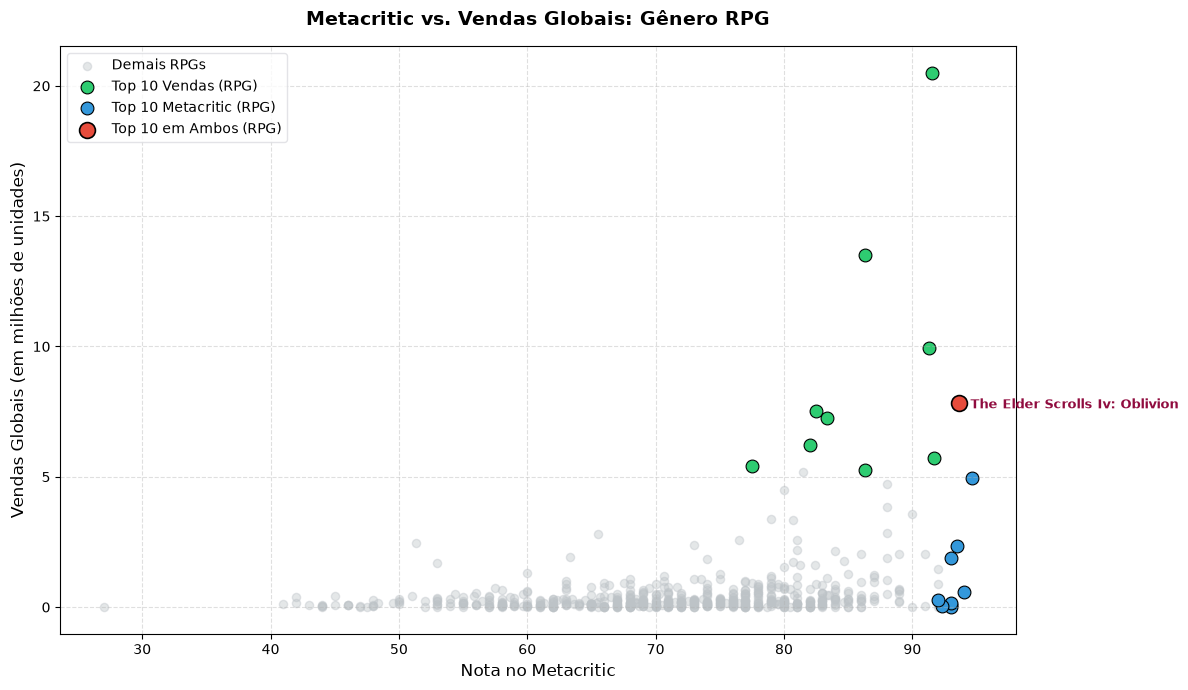

In [10]:
import matplotlib.pyplot as plt


idx_vendas_rpg = set(df_rpg.nlargest(10, 'total_sales').index)
idx_notas_rpg = set(df_rpg.nlargest(10, 'meta_score').index)

idx_ambos_rpg = idx_vendas_rpg.intersection(idx_notas_rpg)
idx_apenas_vendas_rpg = idx_vendas_rpg - idx_ambos_rpg
idx_apenas_notas_rpg = idx_notas_rpg - idx_ambos_rpg
idx_geral_rpg = set(df_rpg.index) - (idx_vendas_rpg | idx_notas_rpg)


df_geral_rpg = df_rpg.loc[list(idx_geral_rpg)]
df_apenas_vendas_rpg = df_rpg.loc[list(idx_apenas_vendas_rpg)]
df_apenas_notas_rpg = df_rpg.loc[list(idx_apenas_notas_rpg)]
df_ambos_rpg = df_rpg.loc[list(idx_ambos_rpg)]


fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(df_geral_rpg['meta_score'], df_geral_rpg['total_sales'], color='#bdc3c7', alpha=0.4, s=35, label='Demais RPGs')
ax.scatter(df_apenas_vendas_rpg['meta_score'], df_apenas_vendas_rpg['total_sales'], color='#2ecc71', s=85, edgecolor='black', linewidth=0.8, label='Top 10 Vendas (RPG)')
ax.scatter(df_apenas_notas_rpg['meta_score'], df_apenas_notas_rpg['total_sales'], color='#3498db', s=85, edgecolor='black', linewidth=0.8, label='Top 10 Metacritic (RPG)')
ax.scatter(df_ambos_rpg['meta_score'], df_ambos_rpg['total_sales'], color='#e74c3c', s=130, edgecolor='black', linewidth=1.2, zorder=5, label='Top 10 em Ambos (RPG)')


for _, row in df_ambos_rpg.iterrows():
    ax.annotate(
        row['title'].title(),
        (row['meta_score'], row['total_sales']),
        xytext=(8, -4),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='#900c3f'
    )

ax.set_title('Metacritic vs. Vendas Globais: Gênero RPG', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nota no Metacritic', fontsize=12)
ax.set_ylabel('Vendas Globais (em milhões de unidades)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(frameon=True, facecolor='white', edgecolor='#dcdde1', loc='upper left')

plt.tight_layout()
plt.show()

In [11]:
df_mestre.to_csv('dados/dataset_final_limpo.csv', index=False)


In [12]:
plt.savefig('imagens/grafico_final.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>